In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [17]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())
print(df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


In [18]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

In [19]:
corr_matrix = df.corr()

print(corr_matrix["MedHouseVal"].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


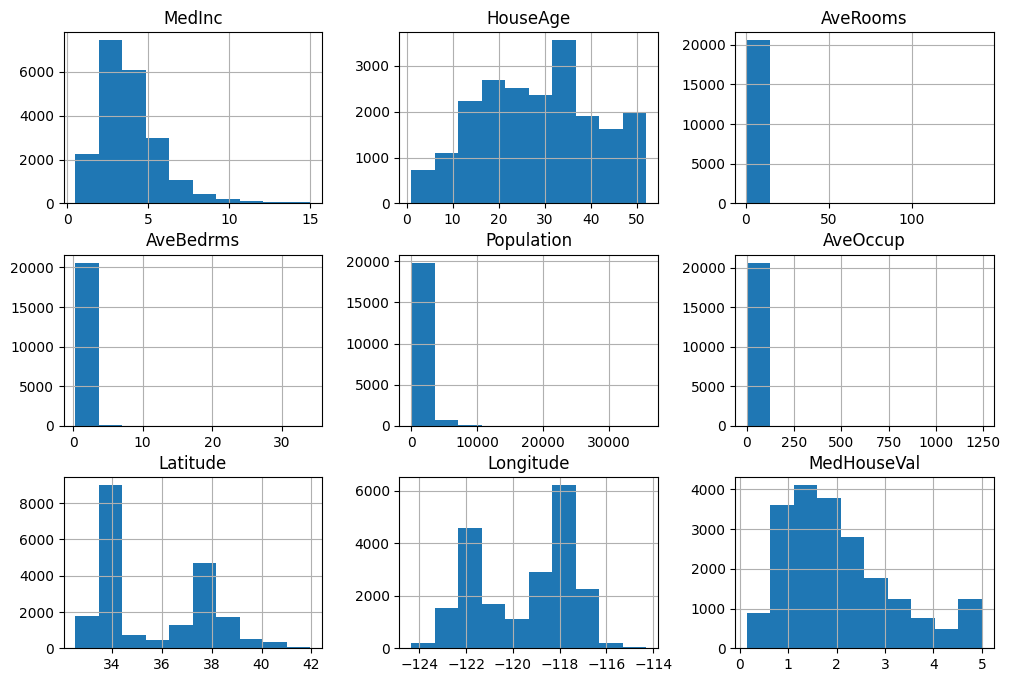

In [20]:
df.hist(figsize=(12,8))

plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test_scaled)

print(predictions[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.5332001304956565
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2: 0.575787706032451


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("R2:",
      r2_score(y_test, rf_pred))

R2: 0.8051230593157366


In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


In [28]:
import joblib

joblib.dump(rf,
            "housing_model.pkl")

['housing_model.pkl']

In [29]:
model = joblib.load(
    "housing_model.pkl"
)

In [30]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load(
    "housing_model.pkl"
)

st.title("California Housing Predictor")

MedInc = st.number_input("Median Income")
HouseAge = st.number_input("House Age")
AveRooms = st.number_input("Average Rooms")
AveBedrms = st.number_input("Average Bedrooms")
Population = st.number_input("Population")
AveOccup = st.number_input("Average Occupancy")
Latitude = st.number_input("Latitude")
Longitude = st.number_input("Longitude")

if st.button("Predict"):

    data = np.array([[
        MedInc,
        HouseAge,
        AveRooms,
        AveBedrms,
        Population,
        AveOccup,
        Latitude,
        Longitude
    ]])

    prediction = model.predict(data)

    st.success(
        f"Predicted Value: ${prediction[0]*100000:.2f}"
    )

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
streamlit run app.py